# IFC2x3 Duplex Architecture COBie Comparison

This notebook compares COBie-related data between:
- Before edit: `JSON Whole Model/Ifc2x3_Duplex_Architecture.json`
- After edit: `JSON_Edit/Ifc2x3_Duplex_Architecture.json`

It first prints the full table with these columns:
- Item Type
- IFC Type
- Total Items
- Name of the model element
- COBie Value

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display

# Show full tables in notebook output (no row truncation).
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

ROOT = Path.cwd().parent
BEFORE_PATH = ROOT / "JSON Whole Model" / "Ifc2x3_Duplex_Architecture.json"
AFTER_PATH = ROOT / "JSON_Edit" / "Ifc2x3_Duplex_Architecture.json"


def _first_property(properties, display_name, category=None):
    display_name_lower = str(display_name).lower()
    category_lower = str(category).lower() if category is not None else None

    for prop in properties:
        prop_name = str(prop.get("displayName", "")).lower()
        prop_category = str(prop.get("category", "")).lower()

        if prop_name != display_name_lower:
            continue
        if category_lower is not None and prop_category != category_lower:
            continue
        return prop
    return None


def extract_table(json_path, dataset_label):
    with open(json_path, "r", encoding="utf-8") as f:
        items = json.load(f)

    prepared = []
    for item in items:
        properties = item.get("Properties", []) if isinstance(item, dict) else []

        type_prop = _first_property(properties, "Type", category="Item") or _first_property(properties, "Type")
        cobie_prop = _first_property(properties, "COBie")
        name_prop = _first_property(properties, "Name", category="Item") or _first_property(properties, "Name")

        model_element_name = item.get("Name") or (name_prop or {}).get("value") or ""
        ifc_type = (type_prop or {}).get("value", "")
        item_type = (type_prop or {}).get("category", "Item")
        cobie_value = (cobie_prop or {}).get("value")

        prepared.append(
            {
                "Dataset": dataset_label,
                "Element Key": item.get("ExternalId") or model_element_name,
                "Item Type": item_type,
                "IFC Type": ifc_type,
                "Name of the model element": model_element_name,
                "COBie Value": cobie_value,
            }
        )

    df = pd.DataFrame(prepared)
    counts = (
        df.groupby("IFC Type", dropna=False)
        .size()
        .rename("Total Items")
        .reset_index()
    )

    df = df.merge(counts, on="IFC Type", how="left")
    ordered_columns = [
        "Dataset",
        "Item Type",
        "IFC Type",
        "Total Items",
        "Name of the model element",
        "COBie Value",
        "Element Key",
    ]
    return df[ordered_columns]

In [2]:
before_df = extract_table(BEFORE_PATH, "Before Edit")
after_df = extract_table(AFTER_PATH, "After Edit")

print(f"Before rows loaded: {len(before_df):,}")
print(f"After rows loaded: {len(after_df):,}")

Before rows loaded: 1,432
After rows loaded: 1,432


## COBie Data implementation

This table shows COBie changes from before edit to after edit, with detailed columns in the requested order.

In [5]:
from IPython.display import HTML

before_cmp = before_df.rename(columns={
    "Item Type": "Before Item Type",
    "IFC Type": "Before IFC Type",
    "Total Items": "Before Total Items",
    "Name of the model element": "Before Name",
    "COBie Value": "Before COBie Value",
})

after_cmp = after_df.rename(columns={
    "Item Type": "After Item Type",
    "IFC Type": "After IFC Type",
    "Total Items": "After Total Items",
    "Name of the model element": "After Name",
    "COBie Value": "After COBie Value",
})

comparison = before_cmp.merge(
    after_cmp,
    on="Element Key",
    how="outer",
)

comparison["Name"] = comparison["After Name"].fillna(comparison["Before Name"])
comparison["Raw IFC Type"] = comparison["After IFC Type"].fillna(comparison["Before IFC Type"])


def normalize_ifc_type(raw_ifc_type):
    return str(raw_ifc_type or "").strip().upper()


def extract_cobie_item_type(cobie_value):
    value = str(cobie_value or "").strip()
    if ":" not in value:
        return ""

    right = value.split(":", 1)[1].strip()
    return right


def infer_item_type(cobie_value, ifc_type):
    cobie_item_type = extract_cobie_item_type(cobie_value)
    if cobie_item_type:
        return cobie_item_type

    normalized_ifc_type = normalize_ifc_type(ifc_type)
    return normalized_ifc_type or "Unclassified"


def prepare_source_table(df):
    prepared = df.copy()
    prepared["IFC Type"] = prepared["IFC Type"].apply(normalize_ifc_type)
    prepared["Item Type"] = prepared.apply(
        lambda row: infer_item_type(row["COBie Value"], row["IFC Type"]),
        axis=1,
    )
    return prepared


def build_order_map(series):
    order = {}
    for raw_value in series:
        value = str(raw_value or "").strip()
        if not value or value in order:
            continue
        order[value] = len(order) + 1
    return order


before_source = prepare_source_table(before_df)
after_source = prepare_source_table(after_df)

item_type_order = build_order_map(pd.concat([
    before_source["Item Type"],
    after_source["Item Type"],
], ignore_index=True))
ifc_type_order = build_order_map(pd.concat([
    before_source["IFC Type"],
    after_source["IFC Type"],
], ignore_index=True))

comparison["IFC Type"] = comparison["Raw IFC Type"].apply(normalize_ifc_type)
comparison["COBie Value"] = comparison["After COBie Value"].fillna(comparison["Before COBie Value"])
comparison["Item Type"] = comparison.apply(
    lambda row: infer_item_type(row["COBie Value"], row["IFC Type"]),
    axis=1,
)

before_val = comparison["Before COBie Value"]
after_val = comparison["After COBie Value"]

comparison["COBie Change"] = "Unchanged"
comparison.loc[before_val.isna() & after_val.notna(), "COBie Change"] = "Added"
comparison.loc[before_val.notna() & after_val.isna(), "COBie Change"] = "Removed"
comparison.loc[
    before_val.notna()
    & after_val.notna()
    & (before_val.astype(str) != after_val.astype(str)),
    "COBie Change",
] = "Updated"

# Keep only records that changed between before and after.
changed_only = comparison[comparison["COBie Change"] != "Unchanged"].copy()

type_counts = pd.concat(
    [
        before_source.groupby("IFC Type", dropna=False).size().rename("Before"),
        after_source.groupby("IFC Type", dropna=False).size().rename("After"),
    ],
    axis=1,
).fillna(0)
total_items_by_ifc = type_counts.max(axis=1).astype(int).to_dict()

item_counts = pd.concat(
    [
        before_source.groupby("Item Type", dropna=False).size().rename("Before"),
        after_source.groupby("Item Type", dropna=False).size().rename("After"),
    ],
    axis=1,
).fillna(0)
total_items_by_item_type = item_counts.max(axis=1).astype(int).to_dict()

changed_only["Total Items count"] = changed_only["IFC Type"].map(total_items_by_ifc)

cobie_data_implementation = changed_only[
    [
        "Item Type",
        "IFC Type",
        "Total Items count",
        "Name",
        "COBie Value",
    ]
].copy()

cobie_data_implementation["_item_order"] = cobie_data_implementation["Item Type"].map(item_type_order).fillna(999)
cobie_data_implementation["_ifc_order"] = cobie_data_implementation["IFC Type"].map(ifc_type_order).fillna(999)

cobie_data_implementation = cobie_data_implementation.sort_values(
    ["_item_order", "_ifc_order", "Name"],
    kind="stable",
    na_position="last",
).drop(columns=["_item_order", "_ifc_order"]).reset_index(drop=True)

# Build grouped table: max 3 rows per Item Type, with total shown below a break line.
max_rows_per_item_type = 3
grouped_rows = []

for item_type, group in cobie_data_implementation.groupby("Item Type", sort=False):
    if group.empty:
        continue

    item_total = total_items_by_item_type.get(item_type, "")
    item_total_text = int(item_total) if pd.notna(item_total) and item_total != "" else ""

    # Show only up to 3 rows per item type.
    grouped_rows.extend(group.head(max_rows_per_item_type).to_dict("records"))

    # Break line row.
    grouped_rows.append(
        {
            "Item Type": "---",
            "IFC Type": "---",
            "Total Items count": "---",
            "Name": "---",
            "COBie Value": "---",
        }
    )

    # Total count row below break line.
    grouped_rows.append(
        {
            "Item Type": "",
            "IFC Type": "",
            "Total Items count": f"Total Items: {item_total_text}",
            "Name": "",
            "COBie Value": "",
        }
    )

    # Blank spacer row between groups.
    grouped_rows.append(
        {
            "Item Type": "",
            "IFC Type": "",
            "Total Items count": "",
            "Name": "",
            "COBie Value": "",
        }
    )

grouped_display_df = pd.DataFrame(grouped_rows)

print("COBie Data implementation summary:")
print(f"Changed rows shown in base data: {len(cobie_data_implementation):,}")
print(f"Displayed max rows per Item Type: {max_rows_per_item_type}")

display(HTML(grouped_display_df.to_html(index=False, escape=False)))

COBie Data implementation summary:
Changed rows shown in base data: 123
Displayed max rows per Item Type: 3


Item Type,IFC Type,Total Items count,Name,COBie Value
"Roofs, floor and paving elements",IFCSLAB,21,Basic Roof:Live Roof over Wood Joist Flat Roof:184483,"EF_30 : Roofs, floor and paving elements"
"Roofs, floor and paving elements",IFCSLAB,21,Floor:127mm Slab on Grade:141232,"EF_30 : Roofs, floor and paving elements"
"Roofs, floor and paving elements",IFCSLAB,21,Floor:127mm Slab on Grade:143106,"EF_30 : Roofs, floor and paving elements"
---,---,---,---,---
,,Total Items: 21,,
,,,,
Walls,IFCWALLSTANDARDCASE,56,Basic Wall:Exterior - Brick on Block:138062,EF_25_10 : Walls
Walls,IFCWALLSTANDARDCASE,56,Basic Wall:Exterior - Brick on Block:138157,EF_25_10 : Walls
Walls,IFCWALLSTANDARDCASE,56,Basic Wall:Exterior - Brick on Block:138237,EF_25_10 : Walls
---,---,---,---,---


## Bubble Chart by IFC Type and COBie Coverage

Bubble size shows total count per IFC Type (from the after-edit dataset). Types with no COBie assignment are shown in light grey.

Total IFC Types plotted: 30
Items with COBie assigned: 123
Items without COBie assigned: 1309
Saved bubble PNG: c:\Git\APS-IFC\GeneratedCharts\Ifc2x3_Duplex_Architecture_ifc_type_cobie_bubble.png


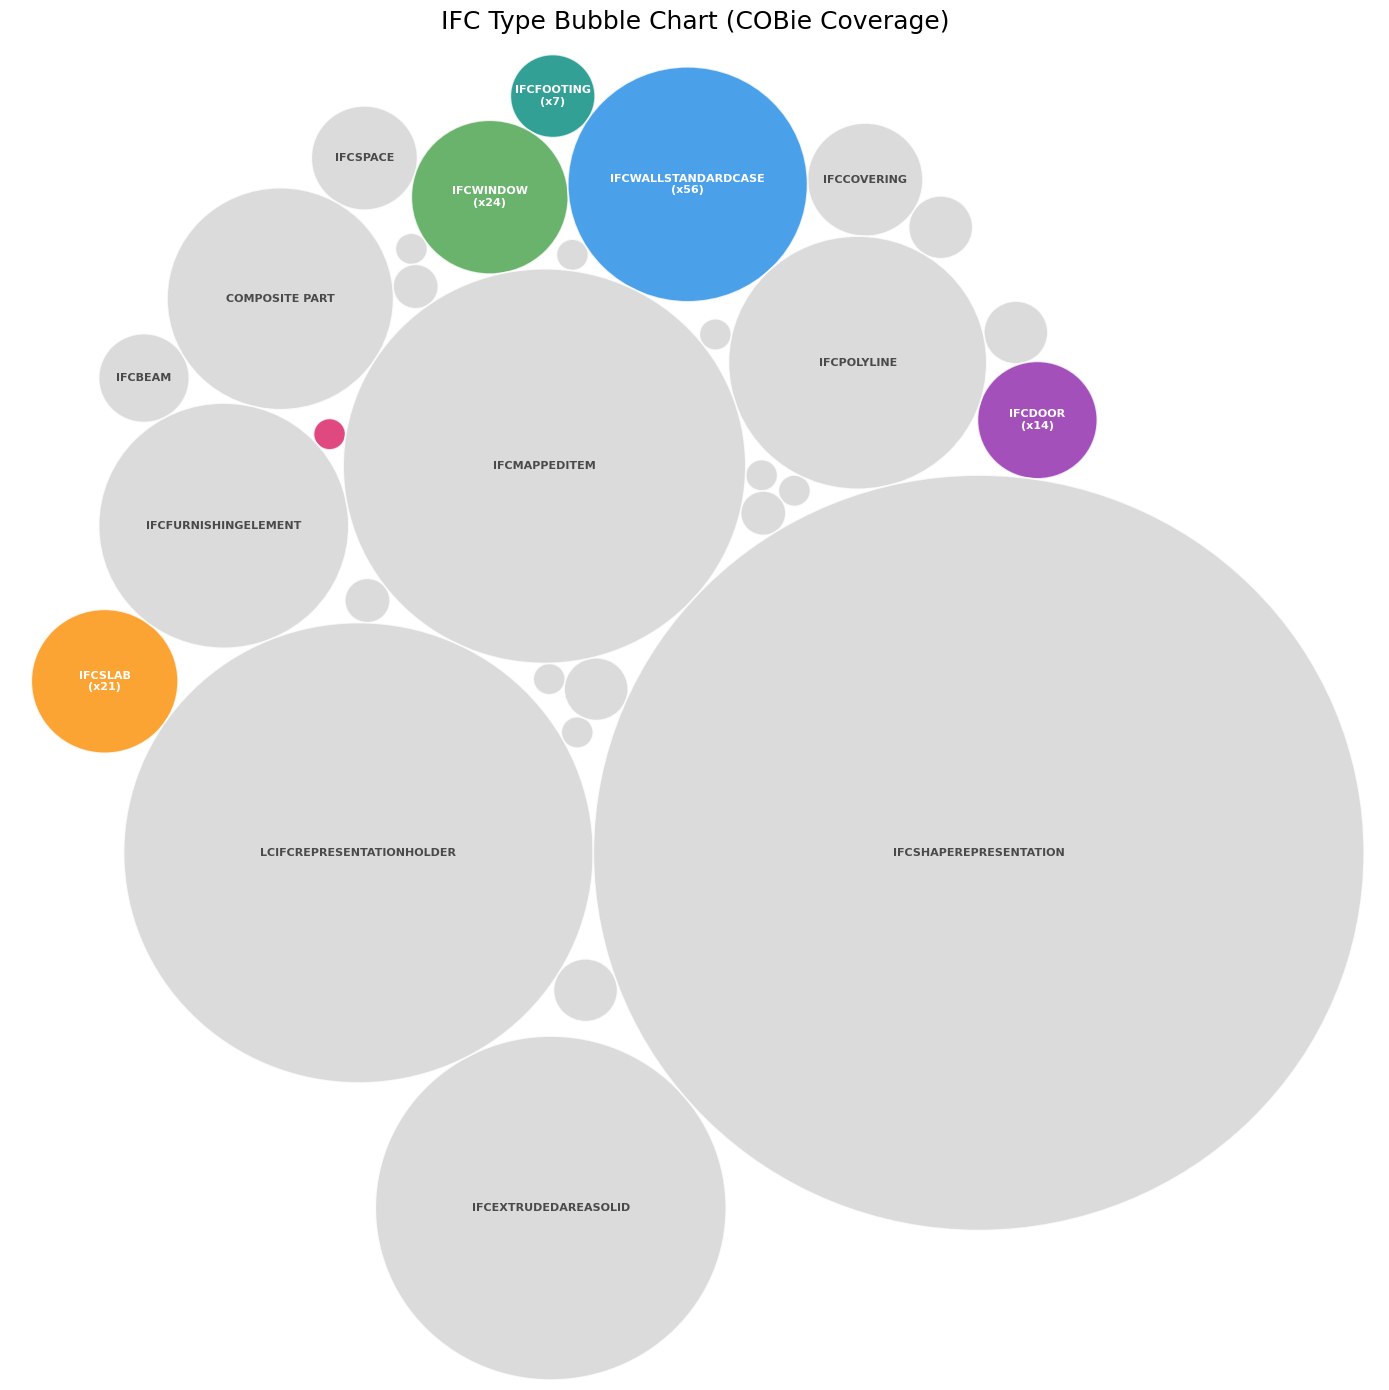

In [7]:
import matplotlib.pyplot as plt

try:
    import circlify
except ImportError:
    print("Package 'circlify' is not installed. Run: %pip install circlify")
else:
    if "after_df" not in globals() or after_df.empty:
        print("No data available. Run the previous cells first.")
    else:
        bubble_df = after_df.copy()
        bubble_df["IFC Type"] = bubble_df["IFC Type"].apply(normalize_ifc_type)

        # Treat null/empty COBie as unassigned.
        cobie_text = bubble_df["COBie Value"].fillna("").astype(str).str.strip()
        bubble_df["Has COBie"] = cobie_text.ne("")

        type_summary = (
            bubble_df.groupby("IFC Type", dropna=False)
            .agg(
                Total_Count=("IFC Type", "size"),
                COBie_Assigned_Count=("Has COBie", "sum"),
            )
            .reset_index()
        )
        type_summary["No_COBie_Count"] = type_summary["Total_Count"] - type_summary["COBie_Assigned_Count"]
        type_summary["Has_Any_COBie"] = type_summary["COBie_Assigned_Count"] > 0

        type_summary = type_summary.sort_values("Total_Count", ascending=False, kind="stable").reset_index(drop=True)

        if type_summary.empty:
            print("No IFC Type data to plot.")
        else:
            type_meta = {
                str(row["IFC Type"]): {
                    "has_cobie": bool(row["Has_Any_COBie"]),
                    "assigned": int(row["COBie_Assigned_Count"]),
                    "unassigned": int(row["No_COBie_Count"]),
                }
                for _, row in type_summary.iterrows()
            }

            circles_data = [
                {"id": str(row["IFC Type"]), "datum": int(row["Total_Count"])}
                for _, row in type_summary.iterrows()
                if int(row["Total_Count"]) > 0
            ]

            circles = circlify.circlify(
                circles_data,
                show_enclosure=False,
                target_enclosure=circlify.Circle(x=0, y=0, r=1),
            )

            fig, ax = plt.subplots(figsize=(14, 14))
            ax.set_title("IFC Type Bubble Chart (COBie Coverage)", fontsize=18)
            ax.axis("off")

            lim = max(
                max(abs(circle.x) + circle.r, abs(circle.y) + circle.r)
                for circle in circles
            )
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)

            assigned_types = type_summary[type_summary["Has_Any_COBie"]]["IFC Type"].tolist()
            assigned_palette = ["#1E88E5", "#43A047", "#FB8C00", "#8E24AA", "#00897B", "#D81B60", "#546E7A", "#FDD835"]
            assigned_color_map = {
                ifc_type: assigned_palette[i % len(assigned_palette)]
                for i, ifc_type in enumerate(assigned_types)
            }

            for circle in circles:
                if circle.level != 1:
                    continue

                x, y, r = circle
                ifc_type = str(circle.ex["id"])
                total_count = int(circle.ex.get("datum", 0))
                has_cobie = bool(type_meta.get(ifc_type, {}).get("has_cobie", False))

                facecolor = assigned_color_map.get(ifc_type, "#D3D3D3") if has_cobie else "#D3D3D3"

                ax.add_patch(
                    plt.Circle(  # type: ignore
                        (x, y),
                        r,
                        alpha=0.8,
                        linewidth=1.2,
                        edgecolor="white",
                        facecolor=facecolor,
                    )
                )

                if r > 0.06:
                    if has_cobie:
                        label = f"{ifc_type}\n(x{total_count})"
                        label_color = "white"
                    else:
                        label = ifc_type
                        label_color = "#4A4A4A"

                    ax.annotate(
                        label,
                        (x, y),
                        ha="center",
                        va="center",
                        fontsize=8,
                        color=label_color,
                        weight="bold",
                    )

            assigned_total = int(type_summary["COBie_Assigned_Count"].sum())
            unassigned_total = int(type_summary["No_COBie_Count"].sum())
            print(f"Total IFC Types plotted: {len(type_summary)}")
            print(f"Items with COBie assigned: {assigned_total}")
            print(f"Items without COBie assigned: {unassigned_total}")

            chart_base_name = BEFORE_PATH.stem
            chart_dir = ROOT / "GeneratedCharts"
            chart_dir.mkdir(parents=True, exist_ok=True)
            bubble_png_path = chart_dir / f"{chart_base_name}_ifc_type_cobie_bubble.png"
            fig.savefig(bubble_png_path, dpi=200, bbox_inches="tight")
            print(f"Saved bubble PNG: {bubble_png_path}")

            plt.tight_layout()
            plt.show()

## Nested Pie Chart by COBie Item Type

Nested pie chart for item groups implied by COBie values. Only items with COBie data are included.

Total COBie item types plotted: 6
Total COBie-assigned items plotted: 123
Saved nested pie PNG: c:\Git\APS-IFC\GeneratedCharts\Ifc2x3_Duplex_Architecture_cobie_nested_pie.png


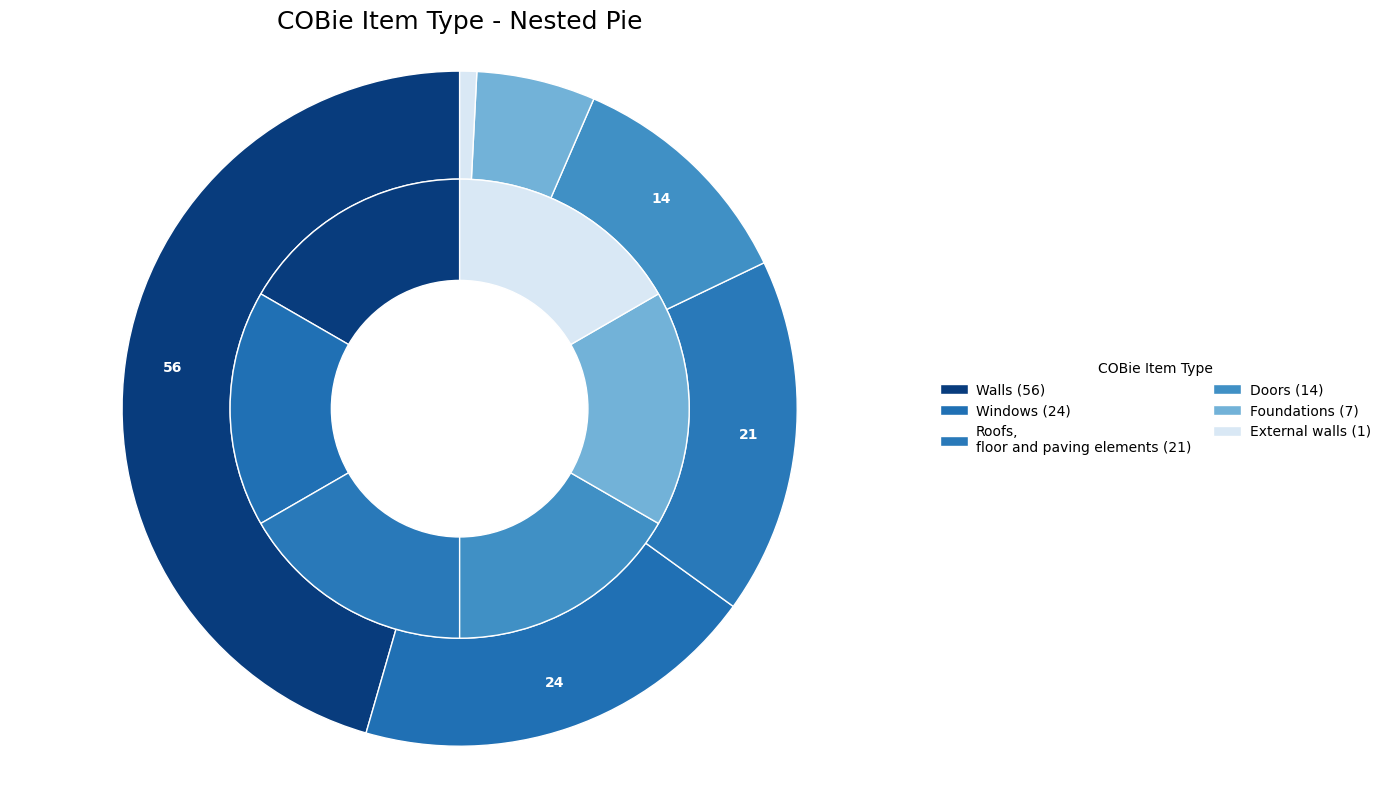

In [8]:
import math
import textwrap

if "after_source" not in globals() or after_source.empty:
    print("No data available. Run the previous cells first.")
else:
    nested_pie_df = after_source.copy()
    nested_pie_df["COBie Value"] = nested_pie_df["COBie Value"].fillna("").astype(str).str.strip()
    nested_pie_df = nested_pie_df[nested_pie_df["COBie Value"].ne("")].copy()

    if nested_pie_df.empty:
        print("No COBie-assigned items available for the nested pie chart.")
    else:
        chart_df = (
            nested_pie_df.groupby("Item Type", dropna=False)
            .size()
            .rename("Count")
            .reset_index()
            .sort_values("Count", ascending=False, kind="stable")
            .reset_index(drop=True)
        )
        chart_df["Item Type"] = chart_df["Item Type"].replace("", "Unclassified")

        min_count = chart_df["Count"].min()
        max_count = chart_df["Count"].max()

        if max_count == min_count:
            normalized = [0.6] * len(chart_df)
        else:
            log_min = math.log1p(min_count)
            log_max = math.log1p(max_count)
            normalized = (chart_df["Count"].apply(math.log1p) - log_min) / (log_max - log_min)

        blues_cmap = plt.get_cmap("Blues")
        colors = [blues_cmap(0.15 + 0.80 * n) for n in normalized]

        inner_values = [1] * len(chart_df)
        outer_values = chart_df["Count"].tolist()
        total_outer = sum(outer_values)

        label_threshold = 11

        def _outer_autopct(pct):
            count = int(round(pct * total_outer / 100.0))
            return f"{count}" if count >= label_threshold else ""

        def _wrap_name(name, max_chars=30):
            parts = [p.strip() for p in str(name).split(",") if p.strip()]
            if len(parts) <= 1:
                return "\n".join(textwrap.wrap(str(name), width=max_chars))

            lines = []
            current = ""
            for part in parts:
                candidate = f"{current}, {part}" if current else part
                if len(candidate) <= max_chars:
                    current = candidate
                else:
                    if current:
                        lines.append(current + ",")
                    current = part
            if current:
                lines.append(current)
            return "\n".join(lines)

        fig, ax = plt.subplots(figsize=(14, 8))

        outer_pie = ax.pie(
            outer_values,
            radius=1.0,
            labels=None,
            colors=colors,
            startangle=90,
            autopct=_outer_autopct,
            pctdistance=0.86,
            wedgeprops={"width": 0.32, "edgecolor": "white", "linewidth": 1},
        )
        outer_wedges = outer_pie[0]
        outer_autotexts = outer_pie[2] if len(outer_pie) > 2 else []

        ax.pie(
            inner_values,
            radius=0.68,
            labels=None,
            colors=colors,
            startangle=90,
            wedgeprops={"width": 0.30, "edgecolor": "white", "linewidth": 1},
        )

        ax.set_title("COBie Item Type - Nested Pie", fontsize=18)
        ax.axis("equal")

        legend_labels = [
            f"{_wrap_name(name)} ({count})"
            for name, count in zip(chart_df["Item Type"], chart_df["Count"])
        ]
        ax.legend(
            outer_wedges,
            legend_labels,
            title="COBie Item Type",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            ncol=2,
            columnspacing=1.6,
            handletextpad=0.6,
            frameon=False,
        )

        for autotext in outer_autotexts:
            autotext.set_color("white")
            autotext.set_fontsize(10)
            autotext.set_fontweight("bold")

        chart_base_name = AFTER_PATH.stem
        chart_dir = ROOT / "GeneratedCharts"
        chart_dir.mkdir(parents=True, exist_ok=True)
        nested_pie_png_path = chart_dir / f"{chart_base_name}_cobie_nested_pie.png"
        fig.savefig(nested_pie_png_path, dpi=200, bbox_inches="tight")
        print(f"Total COBie item types plotted: {len(chart_df)}")
        print(f"Total COBie-assigned items plotted: {total_outer}")
        print(f"Saved nested pie PNG: {nested_pie_png_path}")

        plt.tight_layout()
        plt.show()

## FLIP Standard Donut Chart
This section shows a simple donut chart for the updated FLIP-standard Door and Window counts from the IFC model.
It uses the edited JSON file and plots only `IFCDOOR` and `IFCWINDOW`.

,Chart Label,Count
0,Door,14
1,Window,24


,Chart Label,FLIP IFC Name,Count
0,Door,DOR-SGL-AEC-Metal,14
1,Window,WDW-FXD-AEC-Metal,18
2,Window,WDW-CSM-AEC-Metal,4
3,Window,WDW-SKY-AEC-Metal,2


Total Door + Window items: 38
Saved FLIP donut PNG: c:\Git\APS-IFC\GeneratedCharts\Ifc2x3_Duplex_Architecture_flip_standard_donut.png


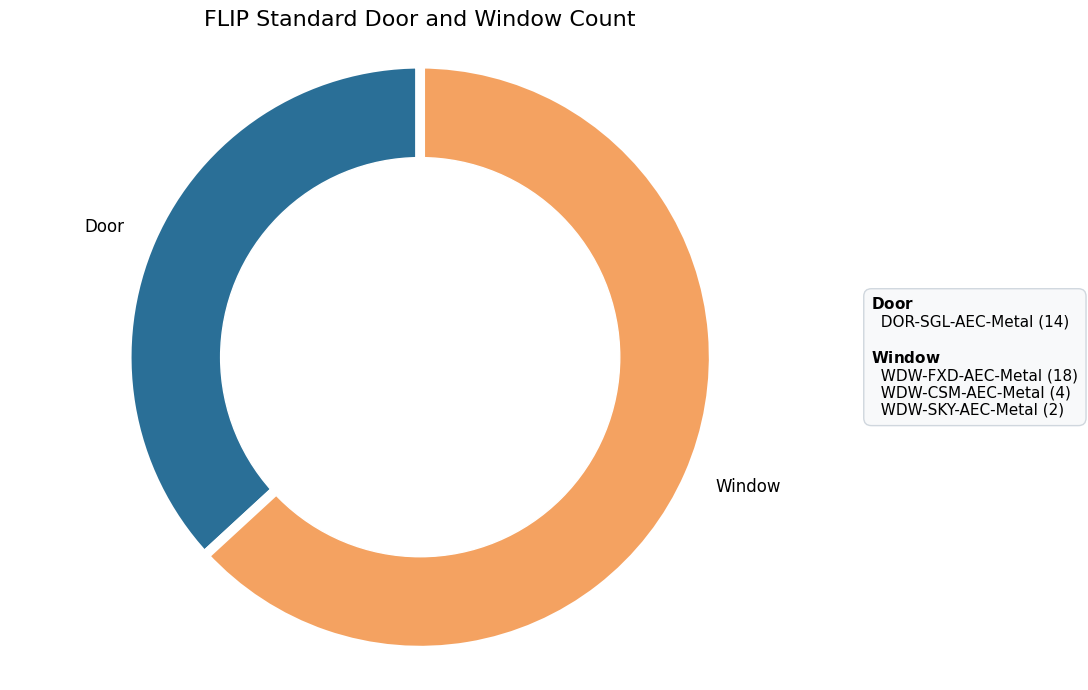

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Circle

chart_root = Path.cwd().parent
flip_after_json_path = chart_root / "JSON_Edit" / "Ifc2x3_Duplex_Architecture.json"

with flip_after_json_path.open("r", encoding="utf-8") as file:
    flip_after_items = json.load(file)

def _find_property(properties, display_name, category=None):
    display_name_lower = str(display_name).strip().lower()
    category_lower = str(category).strip().lower() if category is not None else None

    for prop in properties:
        if not isinstance(prop, dict):
            continue
        prop_name = str(prop.get("displayName", "")).strip().lower()
        prop_category = str(prop.get("category", "")).strip().lower()
        if prop_name != display_name_lower:
            continue
        if category_lower is not None and prop_category != category_lower:
            continue
        return prop
    return None

def _find_exact_property(properties, display_name, category=None):
    for prop in properties:
        if not isinstance(prop, dict):
            continue
        if prop.get("displayName") != display_name:
            continue
        if category is not None and prop.get("category") != category:
            continue
        return prop
    return None

chart_rows = []
for item in flip_after_items:
    if not isinstance(item, dict):
        continue
    properties = item.get("Properties", []) if isinstance(item.get("Properties", []), list) else []
    type_prop = _find_property(properties, "Type", category="Item")
    ifc_name_prop = _find_exact_property(properties, "Name", category="IFC") or _find_property(properties, "Name", category="IFC")

    ifc_type = str((type_prop or {}).get("value", "")).strip().upper()
    if ifc_type not in {"IFCWINDOW", "IFCDOOR"}:
        continue

    chart_rows.append({
        "IFC Type": ifc_type,
        "FLIP IFC Name": str((ifc_name_prop or {}).get("value", "")).strip(),
    })

flip_chart_df = pd.DataFrame(chart_rows)

if flip_chart_df.empty:
    print("No IFCWINDOW or IFCDOOR items found in the edited JSON.")
else:
    label_map = {
        "IFCDOOR": "Door",
        "IFCWINDOW": "Window",
    }
    flip_chart_df["Chart Label"] = flip_chart_df["IFC Type"].map(label_map).fillna(flip_chart_df["IFC Type"])
    flip_chart_df["FLIP IFC Name"] = flip_chart_df["FLIP IFC Name"].replace("", "(missing IFC Name)")

    flip_counts_df = (
        flip_chart_df.groupby(["IFC Type", "Chart Label"], dropna=False)
        .size()
        .rename("Count")
        .reset_index()
        .sort_values(by="IFC Type", kind="stable")
        .reset_index(drop=True)
)

    flip_name_counts_df = (
        flip_chart_df.groupby(["Chart Label", "FLIP IFC Name"], dropna=False)
        .size()
        .rename("Count")
        .reset_index()
        .sort_values(by=["Chart Label", "Count", "FLIP IFC Name"], ascending=[True, False, True], kind="stable")
        .reset_index(drop=True)
)

    display(flip_counts_df[["Chart Label", "Count"]])
    display(flip_name_counts_df)
    print(f"Total Door + Window items: {int(flip_counts_df['Count'].sum())}")

    names = flip_counts_df["Chart Label"].tolist()
    size = flip_counts_df["Count"].tolist()
    colors = ["#2A6F97", "#F4A261"][: len(size)]

    fig, ax = plt.subplots(figsize=(11, 7))
    my_circle = Circle((0, 0), 0.68, color="white")

    pie_result = ax.pie(
        size,
        labels=names,
        colors=colors,
        startangle=90,
        autopct=lambda pct: f"{int(round(pct * sum(size) / 100.0))}",
        wedgeprops={"linewidth": 7, "edgecolor": "white"},
        textprops={"fontsize": 12},
    )
    wedges = pie_result[0]
    texts = pie_result[1]
    autotexts = pie_result[2] if len(pie_result) > 2 else []

    ax.add_artist(my_circle)
    ax.set_title("FLIP Standard Door and Window Count", fontsize=16)
    ax.axis("equal")

    detail_lines = []
    for index, chart_label in enumerate(names):
        if index > 0:
            detail_lines.append("")
        detail_lines.append(rf"$\bf{{{chart_label}}}$")
        label_rows = flip_name_counts_df[flip_name_counts_df["Chart Label"] == chart_label]
        for _, detail_row in label_rows.iterrows():
            detail_lines.append(f"  {detail_row['FLIP IFC Name']} ({int(detail_row['Count'])})")

    ax.text(
        1.05,
        0.5,
        "\n".join(detail_lines),
        transform=ax.transAxes,
        va="center",
        ha="left",
        fontsize=11,
        bbox={"boxstyle": "round,pad=0.5", "facecolor": "#F8F9FA", "edgecolor": "#D0D7DE"},
    )

    for autotext in autotexts:
        autotext.set_color("white")
        autotext.set_fontweight("bold")

    plt.tight_layout()

    chart_base_name = flip_after_json_path.stem
    chart_dir = chart_root / "GeneratedCharts"
    chart_dir.mkdir(parents=True, exist_ok=True)
    flip_donut_png_path = chart_dir / f"{chart_base_name}_flip_standard_donut.png"
    fig.savefig(flip_donut_png_path, dpi=200, bbox_inches="tight")
    print(f"Saved FLIP donut PNG: {flip_donut_png_path}")

    plt.show()